ทำนายว่าลูกค้าจะตกลงทำประกัน/ฝากเงินกับธนาคารหรือไม่จากการตลาดทางโทรศัพท์ /Classification (ทำนายประเภท/กลุ่ม)

ข้อมูลพื้นฐาน

In [2]:
import pandas as pd
df = pd.read_csv('bank.csv')

df.info()

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Missing value

In [3]:
duplicates = df.duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันทั้งหมด: {duplicates} แถว")

missing_values = df.isnull().sum()
print(missing_values)

จำนวนแถวที่ซ้ำกันทั้งหมด: 0 แถว
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


ตรวจสอบOutliers

## การกำจัด Outlier ด้วยวิธี IQR

In [4]:
# สร้าง DataFrame ใหม่สำหรับข้อมูลที่กำจัด outlier แล้ว
df_cleaned = df.copy()

numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # กรองข้อมูลที่ไม่ใช่ outlier ออก
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print(f"จำนวนแถวก่อนกำจัด outlier: {len(df)} แถว")
print(f"จำนวนแถวหลังกำจัด outlier: {len(df_cleaned)} แถว")

display(df_cleaned.head())

จำนวนแถวก่อนกำจัด outlier: 11162 แถว
จำนวนแถวหลังกำจัด outlier: 6498 แถว


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
10,38,admin.,single,secondary,no,100,yes,no,unknown,7,may,786,1,-1,0,unknown,yes


## Boxplots หลังกำจัด Outlier

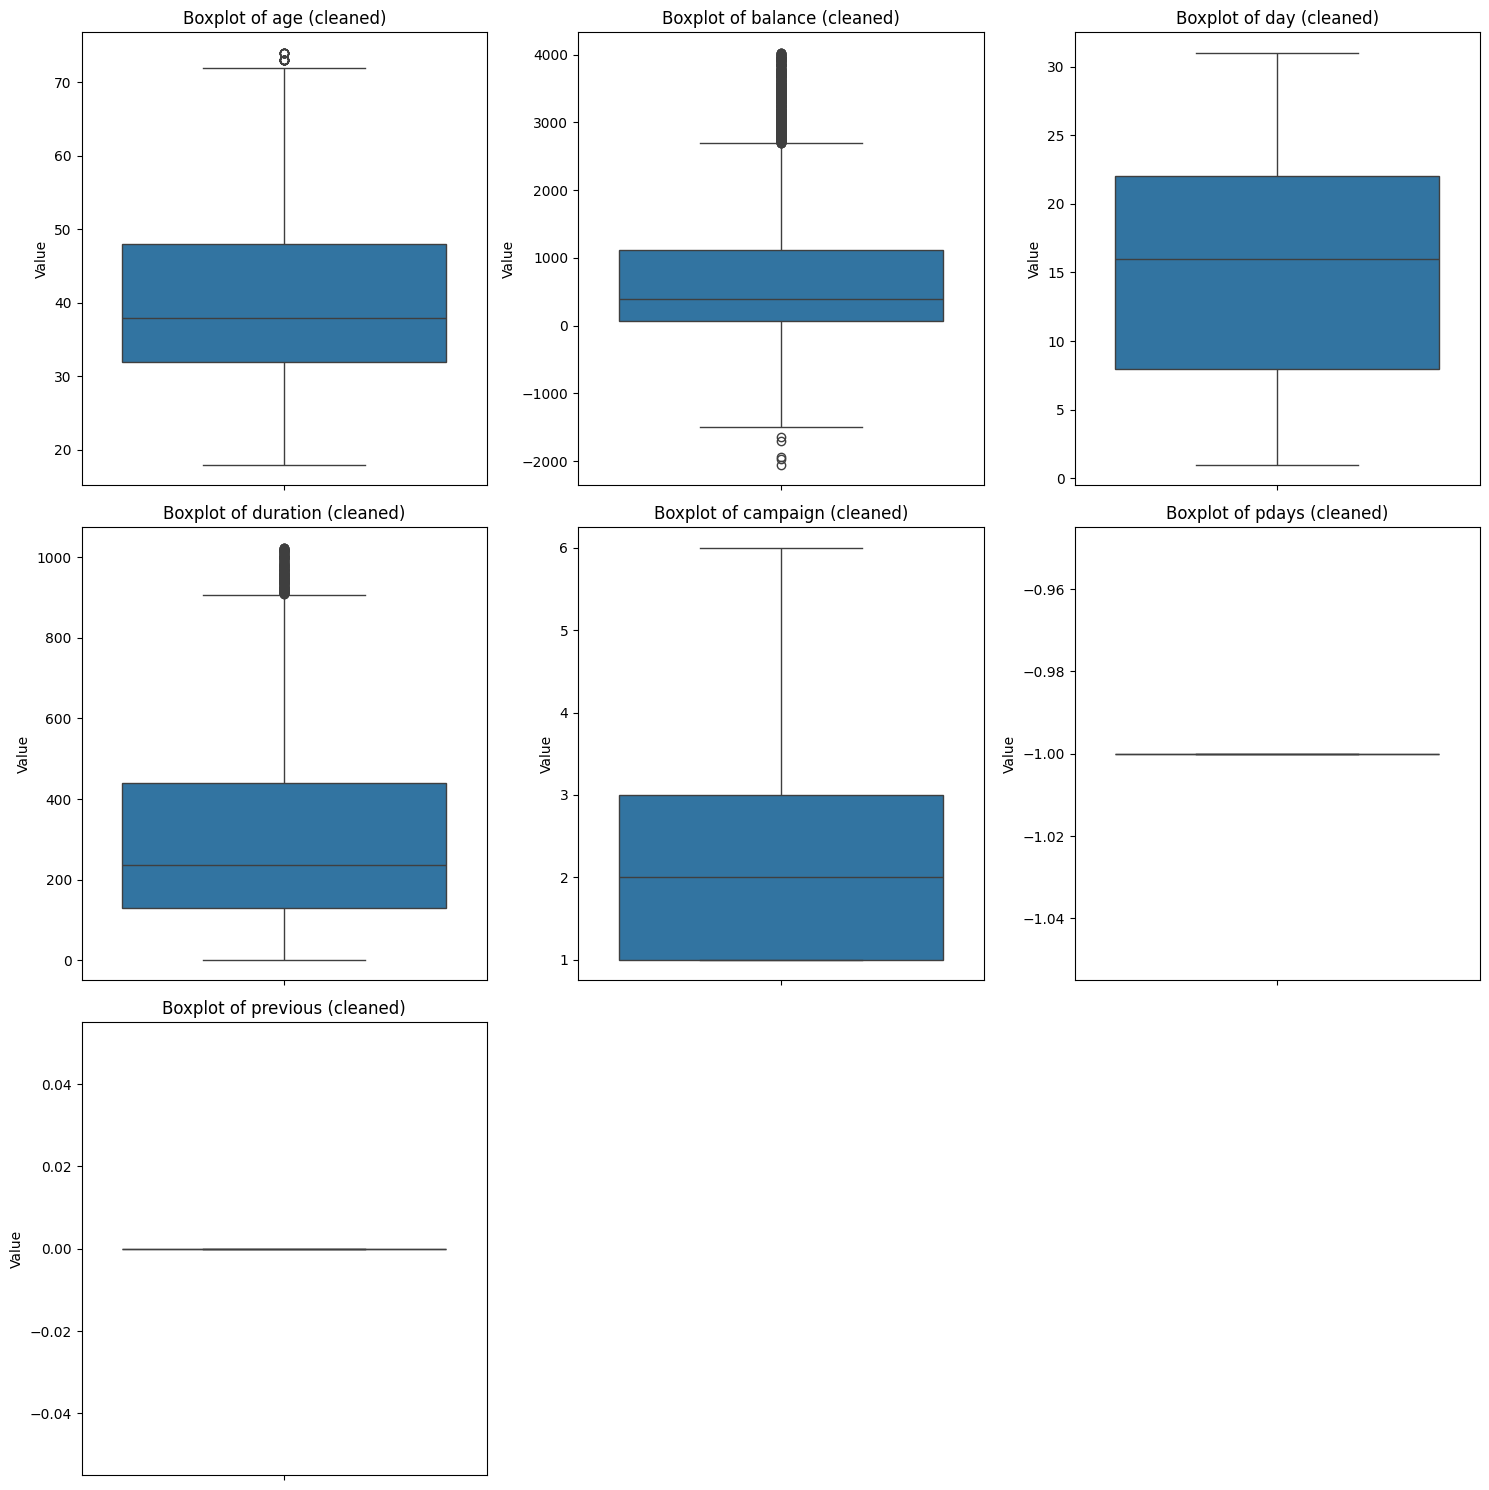

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols_cleaned = df_cleaned.select_dtypes(include=['number']).columns

# กำหนดขนาดของกราฟ
num_cols = 3  # จำนวนคอลัมน์ของ boxplots ต่อแถว
num_rows = (len(numeric_cols_cleaned) + num_cols - 1) // num_cols # คำนวณจำนวนแถวที่ต้องการ

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten() # ทำให้ axes เป็น array 1 มิติ เพื่อให้วนลูปได้ง่ายขึ้น

for i, col in enumerate(numeric_cols_cleaned):
    sns.boxplot(y=df_cleaned[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} (cleaned)')
    axes[i].set_ylabel('Value')

# ซ่อน subplot ที่ไม่ได้ใช้ หากจำนวนคอลัมน์ไม่เต็มแถวสุดท้าย
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

ดูความสัมพันธ์ของข้อมูลแต่ละตัวแปรโดยใช้Correlation Heatmap

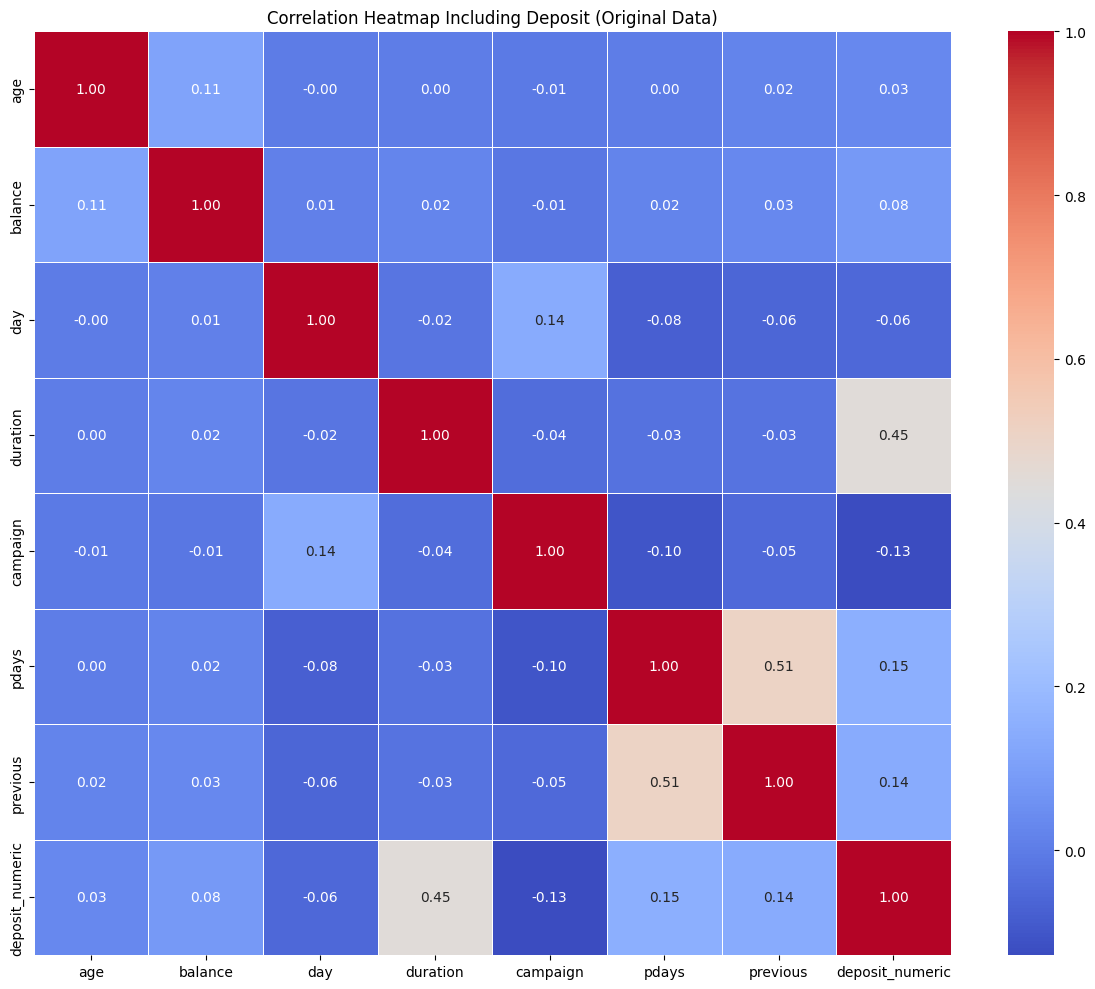

                      age   balance       day  duration  campaign     pdays  \
age              1.000000  0.112300 -0.000762  0.000189 -0.005278  0.002774   
balance          0.112300  1.000000  0.010467  0.022436 -0.013894  0.017411   
day             -0.000762  0.010467  1.000000 -0.018511  0.137007 -0.077232   
duration         0.000189  0.022436 -0.018511  1.000000 -0.041557 -0.027392   
campaign        -0.005278 -0.013894  0.137007 -0.041557  1.000000 -0.102726   
pdays            0.002774  0.017411 -0.077232 -0.027392 -0.102726  1.000000   
previous         0.020169  0.030805 -0.058981 -0.026716 -0.049699  0.507272   
deposit_numeric  0.034901  0.081129 -0.056326  0.451919 -0.128081  0.151593   

                 previous  deposit_numeric  
age              0.020169         0.034901  
balance          0.030805         0.081129  
day             -0.058981        -0.056326  
duration        -0.026716         0.451919  
campaign        -0.049699        -0.128081  
pdays            0

In [6]:
# สร้างคอลัมน์ 'deposit_numeric' โดยแปลง 'yes' เป็น 1 และ 'no' เป็น 0
df['deposit_numeric'] = df['deposit'].map({'yes': 1, 'no': 0})

# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขจาก df (รวมถึง deposit_numeric)
numeric_cols_with_deposit = df.select_dtypes(include=['number'])

# คำนวณ Correlation Matrix
corr_matrix_with_deposit = numeric_cols_with_deposit.corr()

# สร้าง Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_with_deposit, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Including Deposit (Original Data)')
plt.tight_layout()
plt.show()

print(corr_matrix_with_deposit)

# ลบคอลัมน์ชั่วคราวออก
df = df.drop(columns=['deposit_numeric'])

ค่าที่เราต้องการจะทำนายหาคือค่าdeposit

ตัวแปรxที่เลือกมามีดังนี้

**duration** (ค่า Correlation = 0.45): เป็นตัวแปรที่มีความสัมพันธ์สูงสุดกับ deposit (ระยะเวลาการติดต่อครั้งล่าสุด กับลูกค้าคนนั้นๆ ) /ยิ่งใช้ระยะเวลาสนทนานาน โอกาสที่ลูกค้าจะตกลงทำประกัน/ฝากเงินก็ยิ่งสูงขึ้น

**campaign** (ค่า Correlation = -0.13): มีความสัมพันธ์รองลงมาในทิศทางตรงกันข้าม (จำนวนครั้งที่ติดต่อลูกค้าคนนั้นระหว่างแคมเปญปัจจุบัน)  /โทรหาลูกค้าบ่อยๆ ในแคมเปญเดียวกัน อาจจะทำให้ลูกค้ารู้สึกรำคาญจนปฎิเสธข้อเสนอ

**pdays** (ค่า Correlation = 0.15): มีความสัมพันธ์ในระดับใกล้เคียงกับ campaign  (จำนวนวันที่ผ่านไปหลังจากที่ลูกค้าถูกติดต่อครั้งล่าสุดในแคมเปญก่อนหน้า) /ยิ่งลูกค้าถูกติดต่อไม่นานมานี้ อาจมีแนวโน้มที่จะตอบรับข้อเสนอ

**previous** (ค่า Correlation = 0.14): เป็นลำดับที่ 4 ที่มีผลต่อ deposit (จำนวนครั้งที่ลูกค้าถูกติดต่อมาก่อนแคมเปญปัจจุบัน) /หากลูกค้าเคยถูกติดต่อมาหลายครั้งก่อนหน้านี้ อาจมีแนวโน้มที่จะตอบรับข้อเสนอได้บ้าง

ทำการเปรียบเทียบโมเดล3โมเดล 1.Random Forest 2.Support Vector Machine 3.Gradient Boosting และใช้confution matrix เพื่อแสดงผลการทำนายแต่ละโมเดล แสดงค่าaccuracy และ F1Score ของแต่ละโมเดล

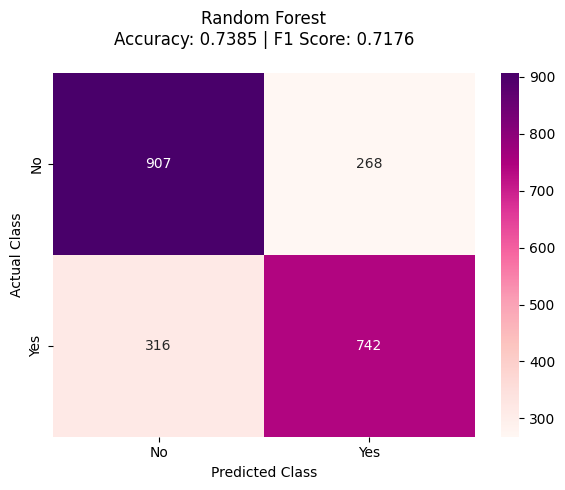

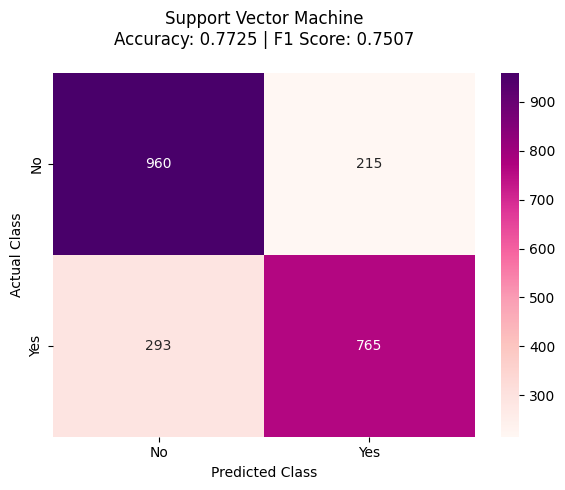

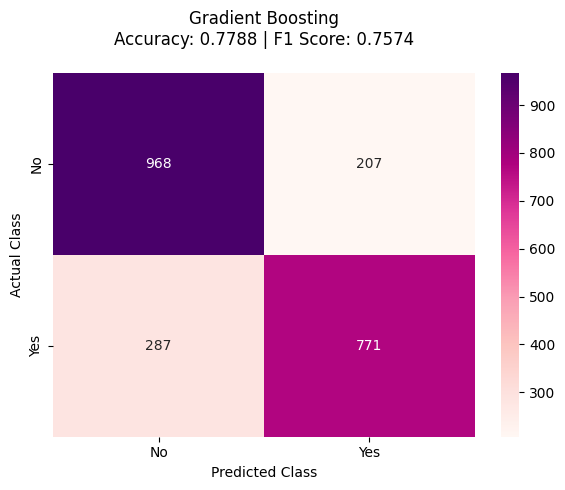

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler



# กำหนด X ด้วยคุณลักษณะที่เลือก และ y เป็นตัวแปรเป้าหมาย 'deposit'
X = df[['duration', 'campaign', 'pdays', 'previous']]
y = df['deposit']

# แปลงคอลัมน์ 'deposit' เป็นค่าตัวเลข (0 สำหรับ 'ไม่', 1 สำหรับ 'ใช่')
y_encoded = y.map({'no': 0, 'yes': 1})

# 2. Scaling ข้อมูล
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)


    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    cm = confusion_matrix(y_test, y_pred)

    # สร้างรูปกราฟ
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

    # แสดงค่า Accuracy และ F1
    plt.title(f'{name}\nAccuracy: {acc:.4f} | F1 Score: {f1:.4f}', fontsize=12, pad=20)
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()


    plt.show()

เลือกโมเดลGradient Boosting เนื่องจากมีค่าAccuracyและF1 Score มากที่สุด

เชื่อมกับเเอพ

In [8]:
import joblib

# สมมติว่าตัวแปรโมเดลของคุณชื่อ 'model' และตัวแปลงข้อมูลชื่อ 'scaler'
joblib.dump(model, 'bank_model.pkl')
joblib.dump(scaler, 'scaler.pkl') # ถ้ามีการทำ Scaling ข้อมูลต้องเซฟไว้ด้วย

['scaler.pkl']